In [10]:
import pandas as pd

df = pd.read_csv('/Users/timfayjr/Desktop/Rize/data_spotify.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


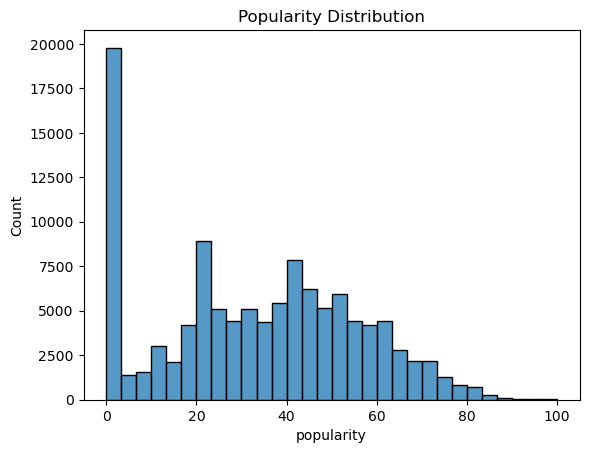

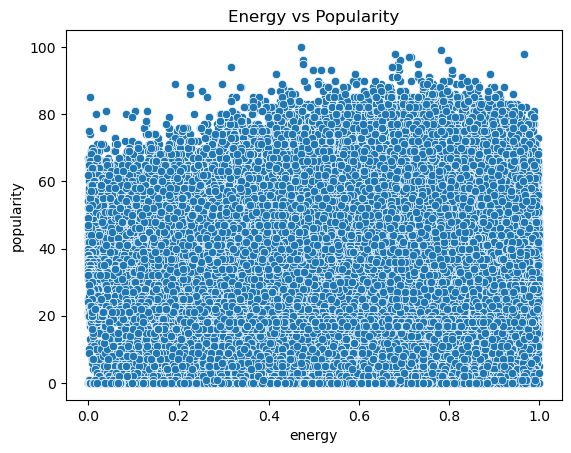

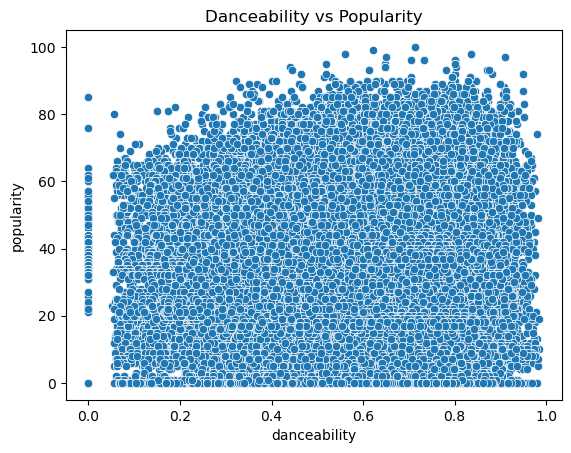

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Popularity distribution
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

# Energy vs Popularity
sns.scatterplot(x='energy', y='popularity', data=df)
plt.title("Energy vs Popularity")
plt.show()

# Danceability vs Popularity
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title("Danceability vs Popularity")
plt.show()

The dataset contains over 100,000 Spotify tracks with audio features such as energy, danceability, and tempo. The target variable, popularity, shows a moderately skewed distribution. Initial visualizations suggest that features like energy and danceability may have some relationship with popularity, indicating potential predictive value for modeling.

In [13]:
# Feature 1
df['energy_dance'] = df['energy'] * df['danceability']

# Feature 2
df['loudness_tempo_ratio'] = df['loudness'] / df['tempo']

# Feature 3
df['acoustic_diff'] = df['acousticness'] - df['instrumentalness']

Feature 1: energy_dance  
This feature multiplies energy and danceability to capture songs that are both energetic and danceable. These songs are often more engaging and may lead to higher popularity.

Feature 2: loudness_tempo_ratio  
This feature represents the intensity of a song relative to its speed. Louder and faster songs may be perceived as more exciting, influencing listener engagement.

Feature 3: acoustic_diff  
This feature captures the difference between acousticness and instrumentalness to distinguish between acoustic and electronic styles, which may impact listener preference.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=['popularity', 'track_name', 'artists'], errors='ignore')
y = df['popularity']

# 🔑 Keep only numeric columns (fixes your error)
X = X.select_dtypes(include=['number'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_rmse

np.float64(14.40223385253074)

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_rmse

np.float64(21.972634073219435)

In [25]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rf_rmse, lr_rmse]
})

comparison

,Model,RMSE
0,Random Forest,14.402234
1,Linear Regression,21.972634


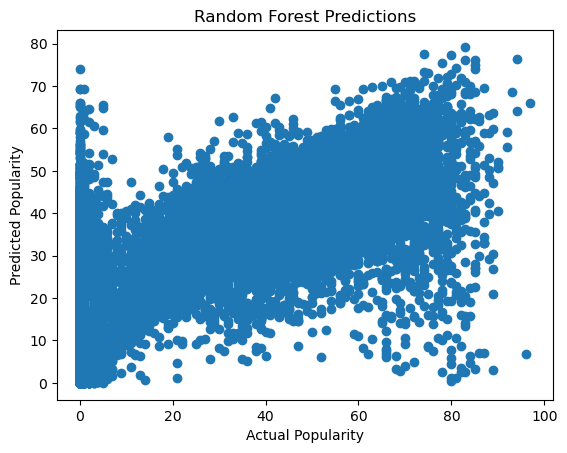

In [26]:
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest Predictions")
plt.show()

The Random Forest model outperformed Linear Regression, likely because it captures nonlinear relationships between audio features and popularity. Linear Regression assumes a linear relationship, which may oversimplify the problem.

The trade-off is that Random Forest is less interpretable and more computationally expensive, while Linear Regression is simple and fast.

For the final project, Random Forest will likely be the preferred model due to its higher predictive accuracy.

## Reflection and Next Steps

### Feature Engineering Plans
For the final submission, I plan to create additional features to better capture the patterns driving song popularity. These will include:
- **Genre encoding**: Converting categorical genres into numeric features using one-hot encoding.
- **Interaction terms**: For example, combining `valence` with `energy` to capture “happy energetic songs”.
- **Rolling averages**: For artists with multiple songs, computing average popularity as a contextual feature.
- **Release year features**: Normalizing popularity based on year released to account for trends over time.

These additional features aim to capture temporal and stylistic patterns that the current features may not fully represent.

### Model Optimization Plans
The Random Forest model currently performs better than Linear Regression, but there is room for improvement. Plans include:
- **Hyperparameter tuning**: Adjusting `n_estimators`, `max_depth`, and `min_samples_split` to improve accuracy without overfitting.
- **Cross-validation**: Using k-fold cross-validation to ensure stability of the results.
- **Feature selection**: Removing redundant or low-importance features to reduce noise and improve interpretability.

### Questions for Instructor Feedback
- Are there additional features you recommend that could capture listener behavior more effectively?
- Would incorporating temporal trends (e.g., release year popularity trends) significantly improve model performance?
- Is the approach of using Linear Regression as a baseline and Random Forest for the main model appropriate for this type of regression problem?

Overall, this draft demonstrates the ability to load data, engineer meaningful features, implement two models, and evaluate performance. The next steps focus on enriching features and tuning the models for the final submission.